### モンテカルロ法

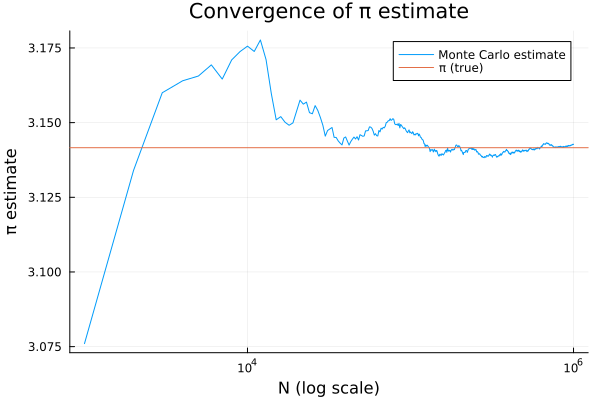

推定された円周率 = 3.142696
誤差 = 0.001103346410206818


In [7]:
using Random
using Plots
gr()  # グラフバックエンドの指定

# モンテカルロ法による円周率の推定（途中経過つき）
function estimate_pi_with_plot(N; seed=1234, every=1000)
    Random.seed!(seed)

    inside = 0
    pi_hats = Float64[]   # 推定値の履歴
    ns = Int[]            # 試行回数の履歴

    for i in 1:N
        x = rand()
        y = rand()
        if x^2 + y^2 ≤ 1
            inside += 1
        end

        # every 回ごとに記録
        if i % every == 0
            push!(ns, i)
            push!(pi_hats, 4 * inside / i)
        end
    end

    # プロット
    p = plot(
        ns, pi_hats,
        xscale = :log10,
        xlabel = "N (log scale)",
        ylabel = "π estimate",
        label = "Monte Carlo estimate",
        title = "Convergence of π estimate"
    )
    hline!([π], label = "π (true)")

    display(p)

    return 4 * inside / N
end

# 実行例
N = 10^6
pi_hat = estimate_pi_with_plot(N; every=1000)

println("推定された円周率 = ", pi_hat)
println("誤差 = ", abs(pi_hat - π))


acceptance rate = 0.7055950932515542
sample mean     = -0.014841159571995811
sample var      = 1.0003372919694737


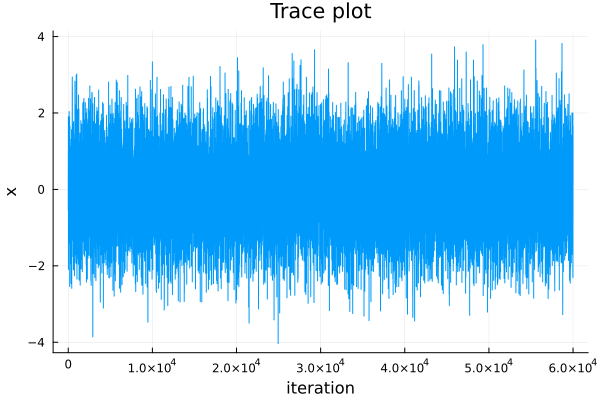

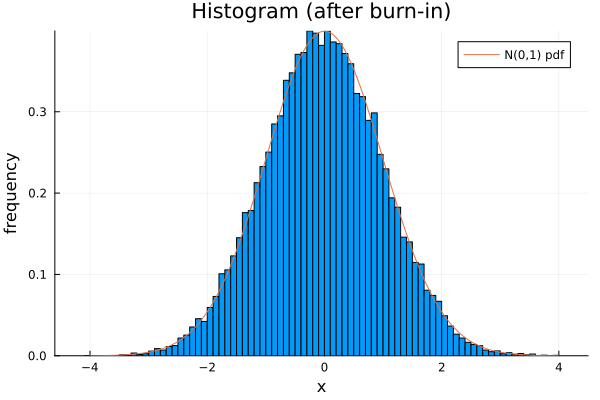

In [11]:
using Random
using Statistics
using Plots
gr()  

# 目的分布の「対数密度」 log π(x) （正規化定数は不要）
# ここでは標準正規: π(x) ∝ exp(-x^2/2)
logpi(x) = -0.5 * x^2

"""
    metropolis(logpi, x0; n=50_000, burn=5_000, step=1.0, seed=1234)

メトロポリス法（対称ランダムウォーク提案）でサンプル生成。
- logpi: 対数密度関数 log π(x)（定数分は不要）
- x0: 初期値
- n: 総反復回数
- burn: バーンイン（捨てる最初の反復数）
- step: 提案の標準偏差 s（大きいと棄却増、小さいと移動が遅い）
- seed: 乱数シード

戻り値:
- samples: バーンイン後のサンプル
- accept_rate: 受理率
- chain: 全チェーン（診断用）
"""
function metropolis(logpi, x0; n=50_000, burn=5_000, step=1.0, seed=1234)
    n ≤ 0 && throw(ArgumentError("n must be positive"))
    burn < 0 && throw(ArgumentError("burn must be nonnegative"))
    burn ≥ n && throw(ArgumentError("burn must be < n"))
    step ≤ 0 && throw(ArgumentError("step must be positive"))

    rng = MersenneTwister(seed)

    chain = Vector{Float64}(undef, n)
    chain[1] = x0
    accepted = 0

    cur = x0
    cur_logp = logpi(cur)

    @inbounds for t in 2:n
        # 1) 提案（対称）: x' = x + Normal(0, step^2)
        prop = cur + step * randn(rng)
        prop_logp = logpi(prop)

        # 2) 受理確率 α = min(1, exp(logπ(prop)-logπ(cur)))
        logα = prop_logp - cur_logp

        # 3) 受理 or 棄却（log判定にすると安定）
        if log(rand(rng)) ≤ logα
            cur = prop
            cur_logp = prop_logp
            accepted += 1
        end

        chain[t] = cur
    end

    accept_rate = accepted / (n - 1)
    samples = chain[(burn+1):end]
    return samples, accept_rate, chain
end

# ---- 実行例 ----
samples, acc, chain = metropolis(logpi, 0.0; n=60_000, burn=10_000, step=1.0, seed=20260201)

println("acceptance rate = ", acc)
println("sample mean     = ", mean(samples))
println("sample var      = ", var(samples))

# ---- 可視化（時間×状態のトレース、ヒストグラム） ----
p1 = plot(chain, xlabel="iteration", ylabel="x", title="Trace plot", label=false)
display(p1)

p2 = histogram(samples, bins=80, xlabel="x", ylabel="frequency", title="Histogram (after burn-in)", label=false, normalize=true)
# 真の標準正規の密度を重ねる（比較用）
xs = range(-4, 4, length=400)
plot!(p2, xs, (1 / sqrt(2π)) .* exp.(-0.5 .* xs.^2), label="N(0,1) pdf")
display(p2)
